"""
Hi ;)
Feel free to either skim or try out the notebook yourselves, as the very reason that prompted me to create such a thing lies in sharing the set of practices I usually draw upon when doing EDA (exploratory data analysis), IDA (in-depth data analysis), and naive model selection. The whole process was already encapsulated in a Python script/function you can make use of. Please check the auto_Model_Selection.py file.

Please, do not hold back from providing notes for improvement or any sort of constructive feedback.

The document is structured as follows:

** Libraries;

** Utilities;

** Data Analysis;

** Model Selection;
"""


# **Libraries**
Please run for smoothless execution :p

In [2]:
### Common python imports - Starts
import pandas as pd
from matplotlib import pyplot as PLT
import numpy
### Common python imports - Ends

### M.L. specific imports - Starts
from argparse import ArgumentParser
from pycaret.time_series import TSForecastingExperiment
from statsmodels.tsa.stattools import coint, adfuller
import pycaret 
### M.L. specific improts - Ends

# **Utilities**
Needs to be included in any run as well.

In [3]:

def argparser():
    args = ArgumentParser("General variables to be defined beforehand of the execution")
    args.add_argument("--go-p", type=str,default=r"C:\Users\20240091\HTT\HTTStockIndustryRankingTool\Gold and Silver\Data\Gold\Demand and Supply\GDT Tables_Q424_EN.xlsx", help="Path to gold overview")

    args, unknown = args.parse_known_args()
    return args 

args = argparser()

# **Data Analysis**

## 1. **Exploratory Data Analysis**

### Gold Demand vs Supply 
In order to be able to determine whether a certain business establishment (whose activity mainly revolves around the jewelry industry) is actually doing a decent job in capitalizing on gold swings, we must be able to identify in advance when such a decrease or increase in either of the two—demand or supply—becomes prevalent. Only then can we tell with a somewhat increased degree of confidence that the firm X was, say, capable of expanding their gold holdings at the right moment. Nevertheless, a model that is able to predict these "swings" or seasonal trends will be of imperative need.

In [4]:
data = pd.read_excel(args.go_p,sheet_name='Gold Balance',engine='openpyxl')
data[:10]
prices = pd.read_excel(args.go_p, sheet_name='Prices', engine='openpyxl')

#### Supply - Can we predict quarterly the supply of gold?


In [36]:
# ------------------------------------------------------------- ### Scraping Price ### ------------------------------------------------------------- #
gold_price = pd.DataFrame({"Total Price":prices.iloc[4], "Period":prices.iloc[3]}).dropna()
total_gold_price = gold_price[:15].dropna()
total_gold_price.index = total_gold_price['Period']
total_gold_price = total_gold_price.drop(columns=['Period'])


quarter_price_gold = gold_price[16:].dropna()
quarter_price_gold.index = quarter_price_gold['Period']
quarter_price_gold = quarter_price_gold.drop(columns=['Period'])
quarter_price_gold = quarter_price_gold[:-1]
# ------------------------------------------------------------- ### Scraping Price ### ------------------------------------------------------------- #


# ------------------------------------------------------------- ### Scraping Supply ### ------------------------------------------------------------- #
# 1. Scrapping data to create variable of interest: Mine Production, Price, Mine production, Net producer hedging, Recycled gold
mine_production = pd.DataFrame({'Supply':data.iloc[5], 'Quarter period':data.iloc[3]}).dropna()
net_producer = pd.DataFrame({'Net Production':data.iloc[6], 'Quarter period':data.iloc[3]}).dropna()
recycled_gold = pd.DataFrame({'Recycled Gold':data.iloc[7], "Quarter period":data.iloc[3]}).dropna()
total_supply = pd.DataFrame({'Total Supply':data.iloc[8], "Quarter period":data.iloc[3]})

general_mine_production, general_net_producer, general_recycled_gold, general_gold_supply = mine_production[:15].dropna(), net_producer[:15].dropna(), recycled_gold[:15].dropna(), total_supply[:15].dropna()

# 2. Creating time index (Quarter to Month)
general_mine_production.index = general_mine_production['Quarter period'].astype(int).drop(columns='Quarter period')
general_net_producer.index = general_net_producer['Quarter period'].astype(int).drop(columns='Quarter period')
general_recycled_gold.index = general_recycled_gold['Quarter period'].astype(int).drop(columns='Quarter period')

# ------------------------------------------------------------- ### Scraping Supply ### ------------------------------------------------------------- #


# ------------------------------------------------------------- ### Mine Production ### ------------------------------------------------------------- #
mine_production = mine_production[16:].copy() 
extract = mine_production['Quarter period'].str.extract(r'Q(?P<q>\d)\'(?P<y>\d+)')
mine_production['Date_Clean'] = "20" + extract['y'] + "-Q" + extract['q']
mine_production['Date'] = pd.to_datetime(mine_production['Date_Clean'])
# Convert your target data to numeric
mine_production['Supply'] = pd.to_numeric(mine_production['Supply'], errors='coerce')
# Columns we're interested in re-sampling and interpolating
df_monthly_mine_production = (mine_production[['Date', 'Supply']]
              .set_index('Date')
              .sort_index()
              .resample('MS')
              .mean() 
              .interpolate(method='linear'))

# Convert data span back to quarter to eliminate any influences drawn by interpolation;
quarter_mine_production = mine_production.drop(columns=['Quarter period','Date_Clean']).dropna()
quarter_mine_production.index = quarter_mine_production['Date']
quarter_mine_production = quarter_mine_production.drop(columns='Date')

# Convert data span back to quarter to eliminate any influences drawn by interpolation;
quarter_mine_production = mine_production.drop(columns=['Quarter period','Date_Clean']).dropna()
quarter_mine_production.index = quarter_mine_production['Date']
quarter_mine_production = quarter_mine_production.drop(columns='Date')
# ------------------------------------------------------------- ### Mine Production ### ------------------------------------------------------------- #



# ------------------------------------------------------------- ### Net producer ### ------------------------------------------------------------- #

net_producer = net_producer[16:].copy()
extract = net_producer['Quarter period'].str.extract(r'Q(?P<q>\d)\'(?P<y>\d+)')
net_producer['Date_Clean'] = "20" + extract['y'] + "-Q" + extract['q']
net_producer['Date'] = pd.to_datetime(net_producer['Date_Clean'])
# Convert your target data to numeric
net_producer['Net Production'] = pd.to_numeric(net_producer['Net Production'], errors='coerce')
# Columns we're interested in re-sampling and interpolating
df_monthly_net_producer = (net_producer[['Date', 'Net Production']]
              .set_index('Date')
              .sort_index()
              .resample('MS')
              .mean() 
              .interpolate(method='linear'))

# Convert data span back to quarter to eliminate any influences drawn by interpolation;
quarter_net_producer = net_producer.drop(columns=['Quarter period','Date_Clean']).dropna()
quarter_net_producer.index = quarter_net_producer['Date']
quarter_net_producer = quarter_net_producer.drop(columns='Date')

# ------------------------------------------------------------- ### Total supply ### ------------------------------------------------------------- #

# ------------------------------------------------------------- ### Recycled gold### ------------------------------------------------------------- #
recycled_gold = recycled_gold[16:]
extract = recycled_gold['Quarter period'].str.extract(r'Q(?P<q>\d)\'(?P<y>\d+)')
recycled_gold['Date_Clean'] = "20" + extract['y'] + "-Q" + extract['q']
recycled_gold['Date'] = pd.to_datetime(recycled_gold['Date_Clean'])
# Convert your target data to numeric
recycled_gold['Recycled Gold'] = pd.to_numeric(recycled_gold['Recycled Gold'], errors='coerce')
# Columns we're interested in re-sampling and interpolating
df_monthly_recycled_gold = (recycled_gold[['Date', 'Recycled Gold']]
              .set_index('Date')
              .sort_index()
              .resample('MS')
              .mean() 
              .interpolate(method='linear'))

# 1. Convert data span back to quarter to eliminate any influences drawn by interpolation;
quarter_recycle_gold = recycled_gold.drop(columns=['Quarter period','Date_Clean']).dropna()
quarter_recycle_gold.index = quarter_recycle_gold['Date']
quarter_recycle_gold = quarter_recycle_gold.drop(columns='Date')
# ------------------------------------------------------------- ### Recycled gold### ------------------------------------------------------------- #

# ------------------------------------------------------------- ### Total supply ### ------------------------------------------------------------- #
total_supply = total_supply[16:]
extract = total_supply['Quarter period'].str.extract(r'Q(?P<q>\d)\'(?P<y>\d+)')
total_supply['Date_Clean'] = "20" + extract['y'] + "-Q" + extract['q']
total_supply['Date'] = pd.to_datetime(total_supply['Date_Clean'])
# Convert your target data to numeric
total_supply['Total Supply'] = pd.to_numeric(total_supply['Total Supply'], errors='coerce')
# Columns we're interested in re-sampling and interpolating
df_monthly_total_supply = (total_supply[['Date', 'Total Supply']]
              .set_index('Date')
              .sort_index()
              .resample('MS')
              .mean() 
              .interpolate(method='linear'))

# Convert data span back to quarter to eliminate any influences drawn by interpolation;
quarter_total_supply = total_supply.drop(columns=['Quarter period','Date_Clean']).dropna()
quarter_total_supply.index = quarter_total_supply['Date']
quarter_total_supply = quarter_total_supply.drop(columns='Date')


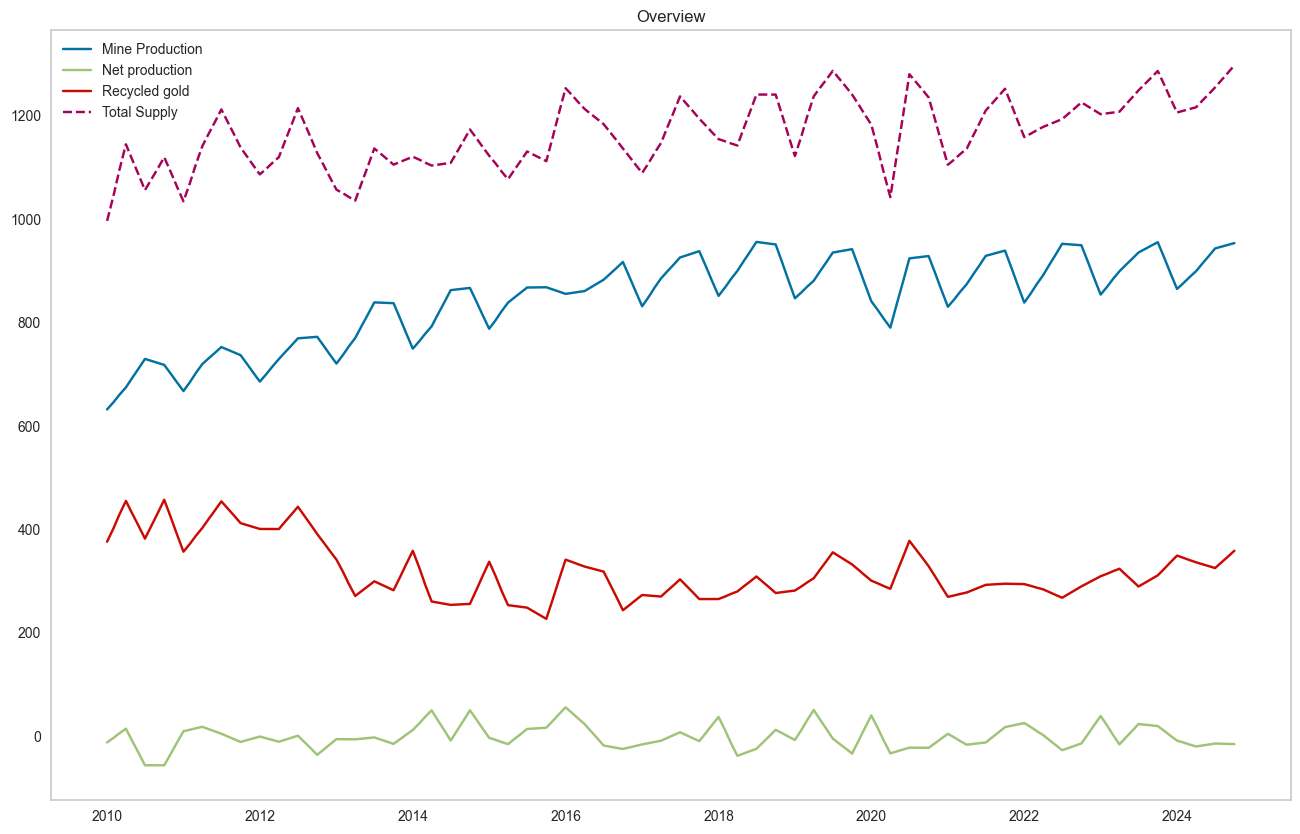

In [7]:
PLT.figure(figsize=(16,10))
PLT.title("Overview")
PLT.plot(df_monthly_mine_production, label = "Mine Production")
PLT.plot(df_monthly_net_producer, label = "Net production")
PLT.plot(df_monthly_recycled_gold, label = "Recycled gold")
PLT.plot(df_monthly_total_supply, label="Total Supply", linestyle='dashed')

PLT.legend()
PLT.grid()


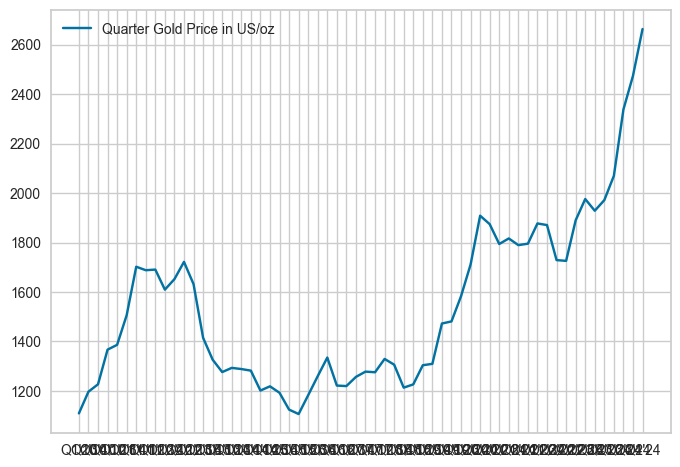

In [40]:
PLT.plot(quarter_price_gold.index, quarter_price_gold, label = 'Quarter Gold Price in US/oz')
PLT.legend()

# **Model selection**

## Naive model selection

### Gold supply

#### Interpolated

In [16]:
# Init the TSForecaster object which allows us use 'setup', 'model_selection' and other py-caret time-series modules;
model = TSForecastingExperiment()
# Setup initi where experiment related settings are being maintained/adjusted
model.setup(df_monthly_total_supply, target='Total Supply',fh=12, fold=5, fold_strategy='expanding', session_id=134)
# Model selection having no imposed any model
_best = model.compare_models(n_select=10, sort='SMAPE')

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "c:\Users\20240091\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [ ]:
# Predicting on the last 12 months/4 quarters
model.predict_model(_best[0])

# Plot the results
model.plot_model(_best[0])

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,ElasticNet,0.5316,0.4881,28.0809,30.7880,0.0225,0.0226,-0.1299


#### Quarter based

In [ ]:
# 2. Set up forecasting experiment;
total_supply_setup = TSForecastingExperiment()
total_supply_setup.setup(quarter_total_supply, 
                         target='Total Supply',
                         fh=12, fold=3, 
                         fold_strategy='expanding')

_best = total_supply_setup.compare_models(n_select=10, sort='SMAPE')
total_supply_setup.predict_model(_best[0])
total_supply_setup.plot_model(_best[0])

,Description,Value
0,session_id,8132
1,Target,Total Supply
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(60, 1)"
5,Transformed data shape,"(60, 1)"
6,Transformed train set shape,"(48, 1)"
7,Transformed test set shape,"(12, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
auto_arima,Auto ARIMA,0.8932,0.9908,55.7600,71.0408,0.0482,0.0481,-0.8923,0.6167
naive,Naive Forecaster,0.9071,1.0062,56.9546,72.4185,0.0493,0.0491,-0.9771,2.8733
grand_means,Grand Means Forecaster,0.9990,1.0229,61.9429,73.2405,0.0518,0.0534,-0.9657,2.0633
arima,ARIMA,1.0078,1.0210,62.4553,73.1078,0.0523,0.0538,-0.9603,0.4600
croston,Croston,0.9997,0.9855,62.7440,70.9056,0.0529,0.0542,-0.9863,0.0367
theta,Theta Forecaster,1.0944,1.1172,74.1694,84.3001,0.0648,0.0636,-2.9430,0.0700
ets,ETS,1.1234,1.1316,78.2025,87.0295,0.0690,0.0666,-4.2712,0.1100
knn_cds_dt,K Neighbors w/ Cond. Deseasonalize & Detrending,1.1776,1.1841,80.5632,90.0862,0.0704,0.0688,-3.9604,0.3667
exp_smooth,Exponential Smoothing,1.1899,1.2155,82.2477,92.8935,0.0722,0.0701,-4.5706,0.0933
polytrend,Polynomial Trend Forecaster,1.1899,1.2155,82.2478,92.8935,0.0722,0.0701,-4.5706,2.0400


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,Auto ARIMA,0.6417,0.6164,42.7775,49.4780,0.0355,0.0348,-0.5251


### Mine Production

#### Interpolated

In [ ]:
# ...zero_grad() lacks thus the cache memory of the gradiens must be erased 'by hand'
model = None
model = TSForecastingExperiment()
# Setup initi where experiment related settings are being maintained/adjusted
model.setup(df_monthly_mine_production, target='Supply',fh=12, fold=5, fold_strategy='expanding', session_id=134)
# Model selection having no imposed any model
_best = model.compare_models(n_select=10, sort='SMAPE')

# Predicting on the last 12 months/4 quarters
model.predict_model(_best[0])

# Plot the results
model.plot_model(_best[0])

,Description,Value
0,session_id,134
1,Target,Supply
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(178, 1)"
5,Transformed data shape,"(178, 1)"
6,Transformed train set shape,"(166, 1)"
7,Transformed test set shape,"(12, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
snaive,Seasonal Naive Forecaster,0.6791,0.7312,18.6232,23.3287,0.0213,0.0212,0.5746,0.0340
arima,ARIMA,0.7620,0.8439,21.1040,26.9576,0.0240,0.0237,0.3532,0.0660
theta,Theta Forecaster,0.7732,0.7764,21.3548,24.6917,0.0245,0.0239,0.4600,0.0240
exp_smooth,Exponential Smoothing,0.8634,0.8288,23.7163,26.3349,0.0271,0.0264,0.4283,0.0600
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,0.9341,0.9253,25.7937,29.4914,0.0292,0.0284,0.2409,0.1900
stlf,STLF,0.9401,0.9488,25.9931,30.3451,0.0294,0.0291,0.2584,0.0280
ets,ETS,0.9591,0.9203,26.4671,29.2722,0.0301,0.0293,0.2439,0.1580
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,1.0282,0.9823,28.3910,31.2792,0.0323,0.0313,0.0615,0.4080
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,1.0297,0.9834,28.4311,31.3135,0.0323,0.0313,0.0595,0.1500
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Detrending,1.0349,0.9924,28.5434,31.5205,0.0327,0.0315,0.0637,0.3120


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,Seasonal Naive Forecaster,0.2091,0.2025,5.2206,6.1535,0.0058,0.0058,0.9554


#### Quarter Based

In [ ]:
# 2. Set up forecasting experiment;
total_supply_setup = TSForecastingExperiment()
total_supply_setup.setup(quarter_mine_production, 
                         target='Supply',
                         fh=12, fold=3, 
                         fold_strategy='expanding')

_best = total_supply_setup.compare_models(n_select=10, sort='SMAPE')
total_supply_setup.predict_model(_best[0])
total_supply_setup.plot_model(_best[0])

,Description,Value
0,session_id,409
1,Target,Supply
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(60, 1)"
5,Transformed data shape,"(60, 1)"
6,Transformed train set shape,"(48, 1)"
7,Transformed test set shape,"(12, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
arima,ARIMA,1.3442,1.3717,38.7804,44.9494,0.0446,0.0431,-0.2786,0.1133
stlf,STLF,1.3795,1.3995,39.6461,45.7048,0.0458,0.0444,-0.2837,0.0667
theta,Theta Forecaster,1.4112,1.4039,40.2361,45.1848,0.0465,0.0459,-0.0258,0.1133
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Detrending,1.4591,1.4062,42.2557,46.3514,0.0489,0.0469,-0.4584,0.2433
ets,ETS,1.4801,1.4731,42.6532,48.2509,0.0492,0.0475,-0.4620,0.1367
exp_smooth,Exponential Smoothing,1.4803,1.4735,42.6596,48.2655,0.0492,0.0475,-0.4624,0.0967
dt_cds_dt,Decision Tree w/ Cond. Deseasonalize & Detrending,1.4854,1.4619,43.5818,48.6465,0.0498,0.0477,-0.5665,0.2967
ada_cds_dt,AdaBoost w/ Cond. Deseasonalize & Detrending,1.5021,1.4557,43.5212,47.9612,0.0503,0.0482,-0.5534,0.2667
et_cds_dt,Extra Trees w/ Cond. Deseasonalize & Detrending,1.5597,1.5095,45.5374,50.1085,0.0523,0.0501,-0.6644,0.4533
omp_cds_dt,Orthogonal Matching Pursuit w/ Cond. Deseasonalize & Detrending,1.5812,1.5623,45.9066,51.3939,0.0526,0.0505,-0.6870,0.2300


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,ARIMA,0.6751,0.6631,18.9680,23.2372,0.0206,0.0203,0.6737


### Net Production

#### Interpolation

In [ ]:
# ...zero_grad() lacks thus the cache memory of the gradiens must be erased 'by hand'
model = None
model = TSForecastingExperiment()
# Setup initi where experiment related settings are being maintained/adjusted
model.setup(df_monthly_net_producer, target='Net Production',fh=12, fold=5, fold_strategy='expanding', session_id=134)
# Model selection having no imposed any model
_best = model.compare_models(n_select=10, sort='SMAPE')

# Predicting on the last 12 months/4 quarters
model.predict_model(_best[0])

# Plot the results
model.plot_model(_best[0])

,Description,Value
0,session_id,134
1,Target,Net Production
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(178, 1)"
5,Transformed data shape,"(178, 1)"
6,Transformed train set shape,"(166, 1)"
7,Transformed test set shape,"(12, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
lightgbm_cds_dt,Light Gradient Boosting w/ Cond. Deseasonalize & Detrending,1.1812,1.1077,18.6035,22.9362,2.1003,1.2570,-1.2196,0.2180
theta,Theta Forecaster,1.3950,1.2923,21.9240,26.7112,2.4745,1.2679,-1.8081,0.0540
naive,Naive Forecaster,1.4007,1.2936,22.0165,26.7404,2.4742,1.2724,-1.8255,0.0360
rf_cds_dt,Random Forest w/ Cond. Deseasonalize & Detrending,1.4400,1.3003,22.6242,26.8690,2.7821,1.2827,-1.4471,0.2920
stlf,STLF,1.4550,1.3304,22.8758,27.5059,2.5981,1.2850,-1.9942,0.0400
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,1.9645,1.6204,30.9062,33.3876,3.5947,1.3011,-3.5162,0.2440
ada_cds_dt,AdaBoost w/ Cond. Deseasonalize & Detrending,1.3390,1.2712,21.0052,26.2616,2.0306,1.3015,-1.7692,0.3080
snaive,Seasonal Naive Forecaster,1.3490,1.2576,21.1984,25.9881,2.3970,1.3294,-1.8018,0.0440
arima,ARIMA,1.8159,1.6198,28.5256,33.4368,3.4484,1.3340,-2.7243,0.0500
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Detrending,1.4237,1.2752,22.3416,26.3080,3.1341,1.3642,-1.4405,0.1520


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,LGBMRegressor,0.7396,0.6589,11.7494,13.7008,1.9145,1.1156,-1.7197


#### Quarter based

In [ ]:
# 2. Set up forecasting experiment;
total_supply_setup = TSForecastingExperiment()
total_supply_setup.setup(quarter_net_producer, 
                         target='Net Producer',
                         fh=12, fold=3, 
                         fold_strategy='expanding')

_best = total_supply_setup.compare_models(n_select=10, sort='SMAPE')
total_supply_setup.predict_model(_best[0])
total_supply_setup.plot_model(_best[0])

,Description,Value
0,session_id,8104
1,Target,Net Production
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(60, 1)"
5,Transformed data shape,"(60, 1)"
6,Transformed train set shape,"(48, 1)"
7,Transformed test set shape,"(12, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
ets,ETS,0.9235,0.8893,23.8639,30.0129,1.3570,1.2901,-0.4667,0.1667
et_cds_dt,Extra Trees w/ Cond. Deseasonalize & Detrending,1.0065,0.9360,25.9317,31.5865,1.9096,1.3083,-0.6284,0.5533
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Detrending,1.0972,0.9932,28.2481,33.5193,2.2410,1.3948,-0.8263,0.2533
theta,Theta Forecaster,0.9306,0.8659,24.0685,29.2206,1.3177,1.4418,-0.3912,0.0433
polytrend,Polynomial Trend Forecaster,0.9657,0.8943,24.9961,30.1851,1.3849,1.4490,-0.4812,0.0467
exp_smooth,Exponential Smoothing,0.9657,0.8943,24.9961,30.1851,1.3849,1.4490,-0.4812,0.0633
lightgbm_cds_dt,Light Gradient Boosting w/ Cond. Deseasonalize & Detrending,0.9658,0.8939,24.9966,30.1710,1.3883,1.4496,-0.4796,0.3733
br_cds_dt,Bayesian Ridge w/ Cond. Deseasonalize & Detrending,0.9658,0.8939,24.9975,30.1715,1.3884,1.4497,-0.4796,0.2200
en_cds_dt,Elastic Net w/ Cond. Deseasonalize & Detrending,0.9718,0.8962,25.1482,30.2476,1.4153,1.4577,-0.4875,0.2833
lasso_cds_dt,Lasso w/ Cond. Deseasonalize & Detrending,0.9718,0.8962,25.1468,30.2469,1.4151,1.4577,-0.4874,0.2200


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,ETS,0.8621,0.8567,24.5797,30.9339,1.8221,1.1432,-1.2130


### Recycled gold

#### Interpolation

In [15]:
# ...zero_grad() lacks thus the cache memory of the gradiens must be erased 'by hand'
model = None
model = TSForecastingExperiment()
# Setup initi where experiment related settings are being maintained/adjusted
model.setup(df_monthly_recycled_gold, target='Recycled Gold',fh=12, fold=5, fold_strategy='expanding', session_id=134)
# Model selection having no imposed any model
_best = model.compare_models(n_select=10, sort='SMAPE')

# Predicting on the last 12 months/4 quarters
model.predict_model(_best[0])

# Plot the results
model.plot_model(_best[0])

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "c:\Users\20240091\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

#### Quarter based

In [ ]:
# 2. Set up forecasting experiment;
total_supply_setup = TSForecastingExperiment()
total_supply_setup.setup(quarter_recycle_gold, 
                         target='Recycled Gold',
                         fh=12, fold=3, 
                         fold_strategy='expanding')

_best = total_supply_setup.compare_models(n_select=10, sort='SMAPE')
total_supply_setup.predict_model(_best[0])
total_supply_setup.plot_model(_best[0])

,Description,Value
0,session_id,4867
1,Target,Recycled Gold
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(60, 1)"
5,Transformed data shape,"(60, 1)"
6,Transformed train set shape,"(48, 1)"
7,Transformed test set shape,"(12, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
croston,Croston,1.6396,1.4666,58.1341,65.4874,0.2115,0.1798,-3.1160,0.0300
snaive,Seasonal Naive Forecaster,1.8645,1.6381,66.9900,74.1238,0.2406,0.2099,-4.1950,0.0767
grand_means,Grand Means Forecaster,2.0103,1.7143,72.9453,78.6450,0.2675,0.2226,-4.8038,0.0400
naive,Naive Forecaster,1.8489,1.6324,67.9720,76.5064,0.2391,0.2247,-4.3131,0.0733
theta,Theta Forecaster,2.1571,1.8863,80.0978,89.0783,0.2839,0.2715,-6.2272,0.0433
stlf,STLF,2.1493,1.8832,79.9543,89.7115,0.2833,0.2779,-6.3511,0.0700
arima,ARIMA,2.3258,1.9799,86.4037,94.3191,0.3048,0.3005,-7.2284,0.0600
et_cds_dt,Extra Trees w/ Cond. Deseasonalize & Detrending,2.4491,2.0263,90.4949,95.4082,0.3200,0.3066,-7.0697,0.4000
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Detrending,2.4398,2.1341,90.4120,101.6724,0.3177,0.3125,-8.2074,0.2333
ada_cds_dt,AdaBoost w/ Cond. Deseasonalize & Detrending,2.5403,2.1567,93.6329,101.8999,0.3285,0.3178,-8.0453,0.2567


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,Croston,0.6536,0.5770,23.7598,28.4363,0.0743,0.0762,-0.1372


# **In-depth data analysis**

## Supply

### What component (recycled gold, net production or mine production) is mostly influencing the price movement?
We want to entirely understand the underlying charachteristics that define each of these components in order to be able to engage a suitable/viable forecasting process.
By the book, one will check - by using different tests - the following attributes:
- **Data stationarity**: *Net production of gold turned out ot be of stationary nature. In spite of this finding since its contribution to the total supply is very less this do not bring that much of an improvment in the future forecasting attempts*. *However, by taking each component order 1 integration counterpart we learn that the total supply is **of stationary nature***.
- **Data cointegration**;

Words of caution:
Testing for stationarity by equipping *check_for_stationarity(X=quarter_total_supply, name='total supply')* might not be sufficient as this test is prone to False-Positive errors/Type 1 erros. Consider enforcing the investigaiton by taking the first order (~ I(1)) integraiton of the time series and applying the test

P_value = 0.9335: the series 'total supply' is likely non-stationary
P_value = 0.0000: the series 'net producer' is likely stationary
P_value = 0.0185: the series ' mine production' is likely non-stationary
P_value = 0.0254: the series 'recycle gold' is likely non-stationary
-----------------------#-----------------------#---------------------
P_value = 0.0000: the series 'total supply' is likely stationary
P_value = 0.0000: the series 'net producer' is likely stationary
P_value = 0.1618: the series ' mine production' is likely non-stationary
P_value = 0.1362: the series 'recycle gold' is likely non-stationary


False

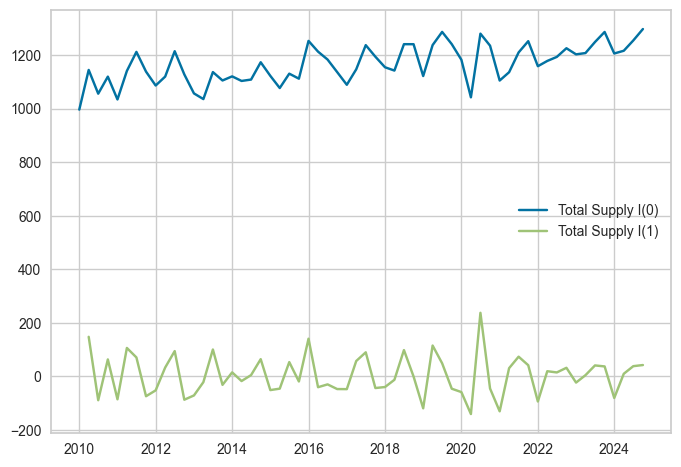

In [ ]:
from StatisticalTestsScripts.stationarity_test import check_for_stationarity

# 1. Check for stationarity by using the raw dataset
check_for_stationarity(x=quarter_total_supply, name='total supply')
check_for_stationarity(x=quarter_net_producer, name='net producer')
check_for_stationarity(x=quarter_mine_production, name=' mine production')
check_for_stationarity(x=quarter_recycle_gold, name='recycle gold')

# 2. Determining whether taking the first order integration of the components 
# ... will change their nature form non-stationarity to statonarity
# e.g., 
PLT.plot(quarter_total_supply, label='Total Supply I(0)')
PLT.plot(quarter_total_supply.diff(), label='Total Supply I(1)')
PLT.legend()
print("-----------------------#-----------------------#---------------------")
check_for_stationarity(x=quarter_total_supply, name='total supply', n_order=1)
check_for_stationarity(x=quarter_net_producer, name='net producer', n_order=1)
check_for_stationarity(x=quarter_mine_production, name=' mine production', n_order=1)
check_for_stationarity(x=quarter_recycle_gold, name='recycle gold', n_order=1)

# 3. Checking for Cointegraiton

# Backlog

In [ ]:
#TODO - Closely examine the effect interpolation operation poses over the model's learning and sense of generalization - Done (pretty much even. No meaningful effect identified)
#TODO - Describe the relationship between gold supply and its price evolution; - perform VAR in order to determine if Total Supply is Impacting the Gold prive and vice-versa;
#Follow up#TODO - And compare the VAR supply against VAR demand;
#TODO - See whether disregarding one of the gold supply components will improve the accuracy and if so under which  circumstances?
#TODO - Create the ensemble (most probably sequential)

# Testing

In [20]:
from test_utils import generate_mock_series
from auto_model_selection import auto_Model_Selection

ImportError: cannot import name 'auto_Model_Selection' from 'auto_model_selection' (d:\Cristi_s_ground\University\HTT\Project\HTTStockIndustryRankingTool\Gold and Silver\auto_model_selection.py)

## *Test 1*
The test verifies whether or not the automatic model selection function behaves as expected when fed with a Pandas dataframe, which entails two columns, `Fiscal Year Period` and `Balance`, respectively.

In [12]:
n_monnths:int = 60
group_1:any = generate_mock_series(n_months=60)
group_1.head()

,Period,Balance
0,201901,1013.861292
1,201902,1019.496651
2,201903,1027.878843
3,201904,1039.321724
4,201905,1051.906137


In [15]:
auto_model_selection(group_1, target_col='Balance')

            Period      Balance
1970-01-01  201901  1013.861292


IndexError: index 1 is out of bounds for axis 0 with size 1